In [1]:
import zipfile
import torch
import io
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import torchvision
import torch.nn as nn
from torchvision import transforms
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
import numpy as np
import os
from scipy.stats import pearsonr
from scipy.signal import butter, sosfiltfilt

In [2]:
os.listdir("/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg")

['Preprocessed_data', 'Image_set', 'Image_feature', 'Image_set_Resize']

In [3]:
def bandpass_filter(
    eeg: np.ndarray,
    lowcut: float = 0.1,
    highcut: float = 20.0,
    fs: float = 250,
    order: int = 5,
) -> np.ndarray:
    if eeg.ndim != 3:
        raise ValueError(f"Expected 3D array (batch, channels, time), got shape {eeg.shape}")

    nyquist = fs / 2.0
    if lowcut <= 0 or highcut >= nyquist:
        raise ValueError(
            f"Cutoff frequencies must satisfy 0 < lowcut < highcut < nyquist ({nyquist} Hz). "
            f"Got lowcut={lowcut}, highcut={highcut}."
        )

    sos = butter(order, [lowcut / nyquist, highcut / nyquist], btype="band", output="sos")

    # Apply filter along time axis for all batch×channels at once
    return sosfiltfilt(sos, eeg, axis=-1)

In [6]:
file_path = "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-01/train.pt"

data = torch.load(file_path, map_location="cpu", weights_only=False)

print(type(data))

additional_subs = ["/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-02/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-03/train.pt",\
                   "/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Preprocessed_data/sub-04/train.pt"]
#additional_subs = []

for i in range(len(additional_subs)):
    print("Sub : ", i + 2)
    new_sub = torch.load(additional_subs[i], map_location="cpu", weights_only=False)
    for j in range (len(new_sub['img'])):
        if new_sub['img'][j] == data["img"][j]:
            data["eeg"][j] += new_sub["eeg"][j]
        else :
            print("Miss : ",new_sub['img'][j], data['img'][j])
            raise ValueError

print("Averaging participants...")
eeg = []

for i in range(len(data["eeg"])):

        data["eeg"][i] /= len(additional_subs) +1
        data["eeg"][i] = bandpass_filter(data["eeg"][i])
        if i%1000 ==0:
            print(i)

print("Finished !")
        

<class 'dict'>
Sub :  2
Sub :  3
Sub :  4
Averaging participants...
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Finished !


In [7]:
print(data["eeg"][0].shape) # First EEG record (time series)
print(data["img"][0]) # Image path associated to First EEG record

(1, 271, 201)
training_images/00001_aardvark/aardvark_01b.jpg


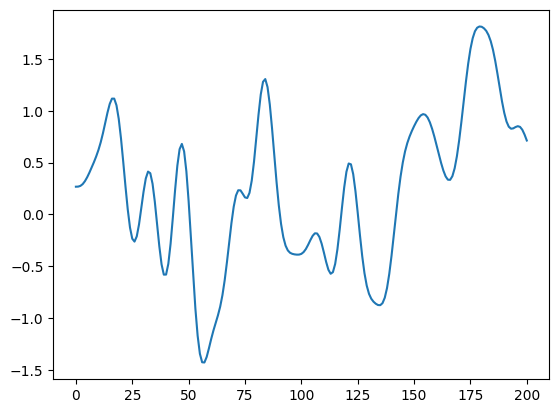

In [8]:
plt.plot(data["eeg"][0].squeeze()[0, :])
plt.show()

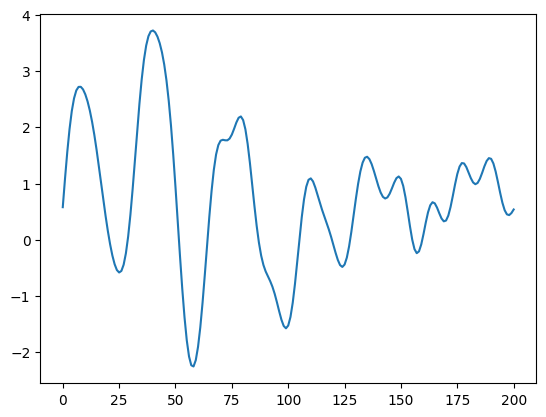

In [20]:
plt.plot(data["eeg"][0].squeeze()[0, :])
plt.show()

In [9]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Authentication : uses kaggle secret to retrieve huggingface token, necessary for access to DINO
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

# Login
login(token=hf_token)

In [10]:
# Load DINO model
from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")
model = AutoModel.from_pretrained("facebook/dinov3-vits16-pretrain-lvd1689m")

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [11]:
output = model(torch.zeros(1,3, 800, 800)) # Run a DINO forward pass on an empty tensor

In [12]:
print(output.last_hidden_state.shape) #Output without pooling
print(output.pooler_output.shape) #Output with pooling

torch.Size([1, 2505, 384])
torch.Size([1, 384])


In [13]:
def make_vgg16_feature_extractor(layer="relu2_2", device="cpu"): # VGG feature extractor to test with VGG model instead of DINO
    """
    Retourne un nn.Module qui sort les features à une couche VGG16 donnée.
    Entrée attendue: images RGB normalisées ImageNet.
    """
    vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1).features

    
    # Mapping couche -> index dans vgg.features
    # VGG16 features indices (conv/relu/pool):
    # relu1_1: 1, relu1_2: 3, pool1: 4
    # relu2_1: 6, relu2_2: 8, pool2: 9
    # relu3_1: 11, relu3_2: 13, relu3_3: 15, pool3: 16
    # relu4_1: 18, relu4_2: 20, relu4_3: 22, pool4: 23
    # relu5_1: 25, relu5_2: 27, relu5_3: 29, pool5: 30
    layer_to_idx = {
        "relu1_1": 1, "relu1_2": 3,
        "relu2_1": 6, "relu2_2": 8,
        "relu3_1": 11, "relu3_2": 13, "relu3_3": 15,
        "relu4_1": 18, "relu4_2": 20, "relu4_3": 22,
        "relu5_1": 25, "relu5_2": 27, "relu5_3": 29,
    }
    if layer not in layer_to_idx:
        raise ValueError(f"Unknown layer {layer}. Choose one of: {list(layer_to_idx.keys())}")

    cut_idx = layer_to_idx[layer]
    extractor = nn.Sequential(*[vgg[i] for i in range(cut_idx + 1)])

    # geler les poids
    for p in extractor.parameters():
        p.requires_grad = False

    extractor.eval().to(device)
    return extractor

extractor = make_vgg16_feature_extractor("relu2_2")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 229MB/s] 


In [14]:
os.listdir("/kaggle/input/datasets/jibrilelhassani/things-meg/things-meg/Image_set/")

['training_images', 'test_images']

In [15]:
base_path = "/kaggle/input/datasets/jibrilelhassani"
root_folder = "/things-meg/things-meg/Image_set/training_images/"
root_path = base_path + root_folder
model_type = "dino"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.eval()
model = model.to(device)
if model_type == "vgg":
    transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
else :
    transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

data_dict = data

image_to_eeg = {
    img_path: torch.tensor(eeg)
    for img_path, eeg in zip(data_dict["img"], data_dict["eeg"])
}

features = []
eeg_list = []
counter = 0

with torch.no_grad():

    # Loop over class folders
    for class_folder in os.listdir(root_path):

        class_path = root_path + class_folder


        if not os.path.isdir(class_path):
            continue

        # Loop over images inside class folder
        for file_name in os.listdir(class_path):
            if not file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            counter += 1

            full_path = class_path + "/" + file_name

            # Build relative path EXACTLY like in zip version
            relative_path = "training_images/" + class_folder + "/" +  file_name
            if relative_path in image_to_eeg:

                img = Image.open(full_path).convert("RGB")
                img_tensor = transform(img).unsqueeze(0).to(device)
                if model_type == "vgg":
                    feat = extractor(img_tensor)
                    feat = torch.nn.functional.adaptive_avg_pool2d(feat, (1, 1))
                    feat = torch.flatten(feat, start_dim=1)

                elif model_type == "dino":
                    feat = model(img_tensor).pooler_output

                features.append(feat.cpu())
                eeg_list.append(image_to_eeg[relative_path])


            if counter % 1000 == 0:
                print(f"Iteration {counter}")

        if counter > 20000:
            break


features = torch.cat(features, dim=0)
eeg_tensor = torch.stack(eeg_list, dim=0)

print("Feature tensor shape:", features.shape)
print("EEG tensor shape:", eeg_tensor.shape)

cuda
Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000
Iteration 5000
Iteration 6000
Iteration 7000
Iteration 8000
Iteration 9000
Iteration 10000
Iteration 11000
Iteration 12000
Iteration 13000
Iteration 14000
Iteration 15000
Iteration 16000
Iteration 17000
Iteration 18000
Iteration 19000
Feature tensor shape: torch.Size([19848, 384])
EEG tensor shape: torch.Size([19848, 1, 271, 201])


In [16]:
eeg_tensor_middle = eeg_tensor[:,:,150,:].squeeze()
print(eeg_tensor_middle.shape)

torch.Size([19848, 201])


In [17]:
eeg_tensor_average = eeg_tensor.mean(2).squeeze()
print(eeg_tensor_average.shape)

torch.Size([19848, 201])


In [18]:
eeg_tensor_chann_average = eeg_tensor.mean(3).squeeze()
print(eeg_tensor_chann_average.shape)

torch.Size([19848, 271])


In [19]:
eeg_tensor_one_channel = eeg_tensor[:,:,:,57].squeeze()
print(eeg_tensor_one_channel.shape)

torch.Size([19848, 271])


In [20]:
eeg_tensor_flatten = eeg_tensor.squeeze()[:,-10:].view(len(eeg_tensor), -1)
print(eeg_tensor_flatten.shape)

torch.Size([19848, 2010])


In [21]:
def train_ridge_model(features, eeg_tensor, verbose = True):
    features_train, features_test, eeg_tensor_train, eeg_tensor_test = train_test_split(features, eeg_tensor, test_size=0.15)
    clf = RidgeCV(alphas=[1e-3, 1e-2, 1e-1, 1]).fit(features_train, eeg_tensor_train)
    
    preds_test = clf.predict(features_test)
    eeg_test_np = np.array(eeg_tensor_test)
    trivial_preds = np.tile(np.array(eeg_tensor_train).mean(0), (len(eeg_test_np), 1))
    if verbose :
        print(f"Train set error {((clf.predict(features_train) - np.array(eeg_tensor_train))**2).mean():4f}")
        print(f"Test set error {((preds_test - eeg_test_np)**2).mean():4f}")
        print(f"Trivial model test set error {((trivial_preds - eeg_test_np)**2).mean():4f}")

    # Pearson correlation per EEG channel, then averaged
    correlations = [pearsonr(preds_test[:, i], eeg_test_np[:, i])[0] for i in range(eeg_test_np.shape[1])]
    if verbose :
        print(f"Test Pearson r (mean over channels): {np.mean(correlations):.4f}")
    
    return np.mean(correlations)

In [22]:
train_ridge_model(features, eeg_tensor_middle)

Train set error 1.028075
Test set error 1.115690
Trivial model test set error 1.100586
Test Pearson r (mean over channels): 0.0363


np.float64(0.03632782403463135)

In [23]:
train_ridge_model(features, eeg_tensor_average)

Train set error 0.073980
Test set error 0.080999
Trivial model test set error 0.079407
Test Pearson r (mean over channels): 0.0186


np.float64(0.01856129598007786)

In [24]:
train_ridge_model(features, eeg_tensor_one_channel)

Train set error 1.079951
Test set error 1.136721
Trivial model test set error 1.129883
Test Pearson r (mean over channels): 0.0843


np.float64(0.08434843167009808)

In [25]:
train_ridge_model(features, eeg_tensor_flatten)

Train set error 1.274038
Test set error 1.355229
Trivial model test set error 1.332031
Test Pearson r (mean over channels): 0.0250


np.float64(0.024951694572341032)

In [26]:
train_ridge_model(features, eeg_tensor_chann_average)

Train set error 0.705407
Test set error 0.774210
Trivial model test set error 0.760742
Test Pearson r (mean over channels): 0.0348


np.float64(0.034763827311271596)

In [27]:
np.random.seed(24)
correlations = []
for timestamp in range(eeg_tensor.shape[-1]):
    
    eeg_tensor_temp = eeg_tensor[:,:,:,timestamp].squeeze()
    correlation = train_ridge_model(features, eeg_tensor_temp, verbose = False)
    correlations.append(correlation)
    if timestamp % 25 == 0:
        print(timestamp)

0
25
50
75
100
125
150
175
200


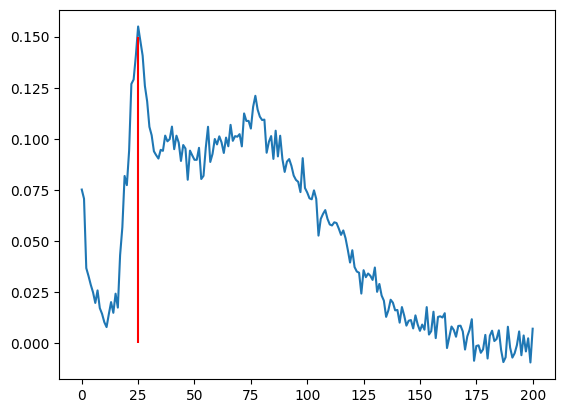

In [29]:
plt.plot(correlations)
plt.vlines(25, 0, 0.16, colors= "r")
plt.show()

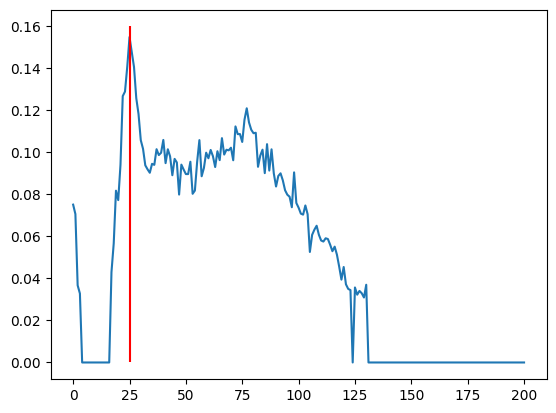

In [31]:
# We put to zero every value that is not statistically significant
for i in range(len(correlations)):
    if correlations[i] < 0.03:
        correlations[i] = 0

plt.plot(correlations)
plt.vlines(25, 0, 0.16, colors= "r")
plt.show()

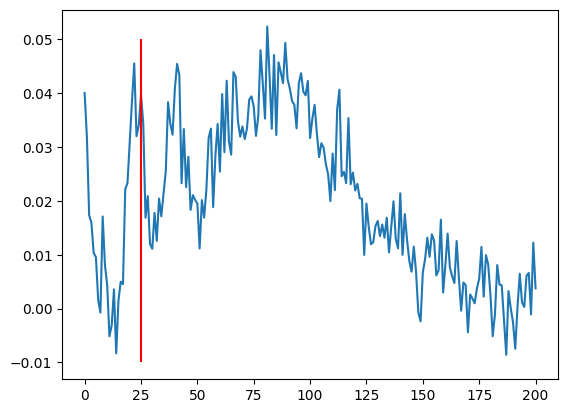

In [52]:
# When no averaging over participants
plt.plot(correlations)
plt.vlines(25, -0.01, 0.05, colors= "r")
plt.show()